A powerful library for NLP and deep learning
models based on the Transformer architecture.

A library for diffusion models (used in image generation like Stable Diffusion).

A library for image processing and manipulation.

A tool to simplify training on GPU/TPU/multi-GPU setups.

A library for mathematics, statistics, and scientific operations.

A safe and fast format for storing model weights (alternative to .pt or .bin).

In [2]:
# !pip install diffusers transformers pillow accelerate scipy safetensors

In [3]:
import torch

In [4]:
from diffusers import StableDiffusionPipeline
from PIL import Image
pipeline = StableDiffusionPipeline.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5", torch_dtype=torch.float16
)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--stable-diffusion-v1-5--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
pipe = pipeline.to("cuda")

In [6]:
prompt = "a photo of an astronaut riding a horse on mars"
image = pipe(prompt).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

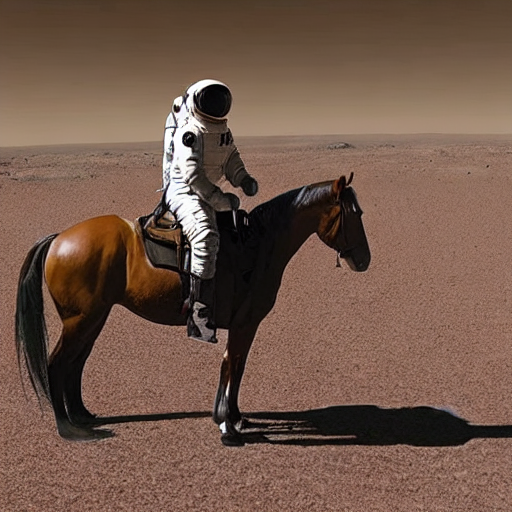

In [7]:
image

In [9]:
!pip install pyngrok

In [10]:
import io
from flask import Flask, request, jsonify, send_file
from PIL import Image
import requests
from io import BytesIO
from pyngrok import ngrok
from google.colab import userdata

In [11]:
app = Flask(__name__)

@app.route('/generate', methods=['POST'])
def generate():
    prompt = request.form.get("prompt_instructions")
    image = pipe(prompt=prompt).images[0]

    # Convert image to byte stream
    img_io = BytesIO()
    image.save(img_io, 'PNG')
    img_io.seek(0)

    return send_file(img_io, mimetype='image/png')

In [14]:
NGROK_AUTH_TOKEN = userdata.get("NGROK_AUTH_TOKEN")
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

public_url = ngrok.connect(5000)
print(f"Server is available at: {public_url}")

app.run(host='0.0.0.0', port=5000)

Server is available at: NgrokTunnel: "https://95be-34-91-17-127.ngrok-free.app" -> "http://localhost:5000"
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit


  0%|          | 0/50 [00:00<?, ?it/s]

INFO:werkzeug:127.0.0.1 - - [20/Apr/2026 04:59:57] "POST /generate HTTP/1.1" 200 -
